In [1]:
import gffutils, os
import pandas as pd

### ok, we need a very-very fast package to work with gff files

In [4]:
# !wget https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_48/gencode.v48.annotation.gtf.gz -O ../../data/gencode.v48.annotation.gtf.gz

In [5]:
# !gunzip ../../data/gencode.v48.annotation.gtf.gz

In [ ]:
# this takes ~8 min at first run

genome_dir = "../../data/annotation"
base_name = "gencode.v48.annotation.gtf"
gff_path = os.path.join(genome_dir, base_name)
db_path = os.path.join(genome_dir, f"{base_name}.db")

if not os.path.exists(db_path):
	db = gffutils.create_db(
		gff_path,
		dbfn=db_path,
		disable_infer_transcripts=True,
		disable_infer_genes=True
	)
else:
	db = gffutils.FeatureDB(db_path)

In [3]:
featuretypes = db.featuretypes()
print (list(featuretypes))

['CDS', 'Selenocysteine', 'UTR', 'exon', 'gene', 'start_codon', 'stop_codon', 'transcript']


In [4]:
%time
features = list(db.region(region=("chr1", 10_000_000, 10_400_000)))
print (len(features))


CPU times: user 1 μs, sys: 1e+03 ns, total: 2 μs
Wall time: 4.53 μs
1505


In [5]:
# get all transcripts in a region
features = list(db.region(region=("chr1", 10_000_000, 10_400_000), featuretype="transcript"))
print (len(features))


54


In [10]:
chroms = [f.chrom for f in db.all_features(featuretype="transcript")]
set(chroms)


{'chr1',
 'chr10',
 'chr11',
 'chr12',
 'chr13',
 'chr14',
 'chr15',
 'chr16',
 'chr17',
 'chr18',
 'chr19',
 'chr2',
 'chr20',
 'chr21',
 'chr22',
 'chr3',
 'chr4',
 'chr5',
 'chr6',
 'chr7',
 'chr8',
 'chr9',
 'chrM',
 'chrX',
 'chrY'}

In [11]:
_ = [f for f in db.all_features(limit="chr1:0-10000000",featuretype="transcript") if "ENST00000476083.1" in f.attributes["transcript_id"]]
print (_[0])

chr1	HAVANA	transcript	8945868	8974874	.	+	.	gene_id "ENSG00000131686.15"; transcript_id "ENST00000476083.1"; gene_type "protein_coding"; gene_name "CA6"; transcript_type "protein_coding_CDS_not_defined"; transcript_name "CA6-204"; level "2"; transcript_support_level "3"; hgnc_id "HGNC:1380"; havana_gene "OTTHUMG00000001763.8"; havana_transcript "OTTHUMT00000004913.1";


In [13]:
list(db.children(features[6]))

[<Feature transcript (chr1:10054445-10054781[-]) at 0x7fd7e9e57940>,
 <Feature exon (chr1:10054445-10054781[-]) at 0x7fd7e9e57310>]

In [ ]:
features[6].attributes.keys()

dict_keys(['gene_id', 'transcript_id', 'gene_type', 'gene_name', 'transcript_type', 'transcript_name', 'level', 'transcript_support_level', 'hgnc_id', 'ont', 'tag', 'havana_gene', 'havana_transcript'])

In [19]:
features[6].attributes["gene_type"], features[6].attributes["tag"], features[6].start, features[6].end, features[6].strand

(['processed_pseudogene'],
 ['pseudo_consens', 'basic', 'Ensembl_canonical', 'GENCODE_Primary'],
 10054445,
 10054781,
 '-')

In [29]:
print ("\n".join(str(features[1]).split("\t")))

chr1
HAVANA
transcript
9997228
10016021
.
+
.
gene_id "ENSG00000162444.12"; transcript_id "ENST00000294435.8"; gene_type "protein_coding"; gene_name "RBP7"; transcript_type "protein_coding"; transcript_name "RBP7-201"; level "2"; protein_id "ENSP00000294435.7"; transcript_support_level "1"; hgnc_id "HGNC:30316"; tag "basic,Ensembl_canonical,GENCODE_Primary,MANE_Select,appris_principal_1,CCDS"; ccdsid "CCDS109.1"; havana_gene "OTTHUMG00000001798.3"; havana_transcript "OTTHUMT00000005027.3";


In [ ]:
all_attributes = {}
# get all possible attribute keys
num_processed = 0
for feature in db.all_features(featuretype="transcript"):
	attributes = feature.attributes
	for key, value in attributes.items():
		if type(value) == str:
			value = value.split(",")
		if key in all_attributes:
			all_attributes[key] += value
		else:
			all_attributes[key] = value
	num_processed += 1
	if num_processed > 100000:
		break

for key, value in all_attributes.items():
	if len(set(value)) > 20:
		print (key, len(set(value)), "values, examples:", sorted(list(set(value)))[:3])
	else:
		print (key, "\n", pd.Series(value).value_counts(),"\n----")	

gene_id 19557 values, examples: ['ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13']
transcript_id 100001 values, examples: ['ENST00000001146.7', 'ENST00000002125.9', 'ENST00000002596.6']
gene_type 21 values, examples: ['IG_C_gene', 'IG_J_gene', 'IG_V_gene']
gene_name 19148 values, examples: ['5S_rRNA', '7SK', 'A3GALT2']
transcript_type 26 values, examples: ['IG_C_gene', 'IG_J_gene', 'IG_V_gene']
transcript_name 100001 values, examples: ['5S_rRNA.10-201', '5S_rRNA.18-201', '5S_rRNA.19-201']
level 
 2    91814
1     5204
3     2983
Name: count, dtype: int64 
----
tag 60 values, examples: ['3_nested_supported_extension', '3_standard_supported_extension', '454_RNA_Seq_supported']
transcript_support_level 
 1     10418
5      9966
2      9552
3      8290
NA     6632
4      3916
Name: count, dtype: int64 
----
havana_transcript 53567 values, examples: ['OTTHUMT00000001178.4', 'OTTHUMT00000001179.3', 'OTTHUMT00000001200.1']
hgnc_id 10512 values, examples: ['HGNC:10000', 'HGNC:1

In [14]:
pd.Series(all_attributes["tag"]).value_counts()

TAGENE                            43436
basic                             40375
GENCODE_Primary                   24816
Ensembl_canonical                 19557
CCDS                              12471
RNA_Seq_supported_only             7880
appris_principal_1                 5983
mRNA_end_NF                        5461
MANE_Select                        4833
cds_end_NF                         4370
alternative_5_UTR                  4010
mRNA_start_NF                      3724
cds_start_NF                       3032
exp_conf                           2837
pseudo_consens                     2368
not_organism_supported             1157
appris_alternative_2                918
CAGE_supported_TSS                  875
RNA_Seq_supported_partial           845
appris_alternative_1                817
nested_454_RNA_Seq_supported        668
inferred_transcript_model           665
appris_principal_4                  641
454_RNA_Seq_supported               592
readthrough_transcript              549


In [ ]:
n_lncRNA = 0
n_protein_coding = 0
n_other = 0
for feature in db.all_features(featuretype="transcript"):
	tags = feature.attributes.get("tag", "unknown")
	transcript_types = feature.attributes.get("transcript_type", ["unknown"])
	filter1 = any(tag in tags for tag in ["GENCODE_Primary", "MANE_Select"])
	prot_coding = any(transcript_type in transcript_types for transcript_type in ["protein_coding"])
	lncRNA = any(transcript_type in transcript_types for transcript_type in ["lncRNA"])
	if filter1 and prot_coding:
		n_protein_coding += 1
	elif filter1 and lncRNA:
		n_lncRNA += 1
	elif filter1:
		n_other += 1
print (f"n_protein_coding: {n_protein_coding}, n_lncRNA: {n_lncRNA}, n_other: {n_other}")


n_protein_coding: 40090, n_lncRNA: 34846, n_other: 24109


In [11]:
n_protein_coding / (n_protein_coding + n_lncRNA + n_other)

0.4047655106264829

In [12]:
n_lncRNA / (n_protein_coding + n_lncRNA + n_other)

0.3518198798525923

In [9]:
34846 / (40090 + 34846)

0.46501014198782964

### tokenizer experiments

In [18]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("AIRI-Institute/gena-lm-bert-base-t2t")

/disk/10tb/home/fishman/miniconda3/envs/bert24/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
tok("N")

{'input_ids': [1, 12, 2], 'token_type_ids': [0, 0, 0], 'attention_mask': [1, 1, 1]}

In [ ]:
encoding = tok(
			"ATGAAATAGATGATGACCAGATGANATANNNNNNNNNNNNNNNNNNNNNNNNATA",
			return_tensors='pt',
			return_offsets_mapping=True,
			add_special_tokens=True,
			truncation=True,
			max_length=20,
			padding='max_length'
		)


In [ ]:
for k, v in encoding.items():
	print (k,":",v)


input_ids : tensor([[    1,    28,   728,   432, 11113,  3777,  1683,     5,  1683,     2,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3]])
token_type_ids : tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
attention_mask : tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
offset_mapping : tensor([[[ 0,  0],
         [ 0,  3],
         [ 3,  9],
         [ 9, 15],
         [15, 23],
         [23, 25],
         [25, 28],
         [51, 52],
         [52, 55],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0],
         [ 0,  0]]])


In [ ]:
for om,t in zip(encoding['offset_mapping'][0], encoding['input_ids'][0]):
	print (t.item(),om.numpy(),tok.decode(t.item()))

1 [0 0] [CLS]
28 [0 3] ATG
728 [3 9] AAATAG
432 [ 9 15] ATGATG
11113 [15 23] ACCAGATG
3777 [23 25] AN
1683 [25 28] ATA
5 [51 52] -
1683 [52 55] ATA
2 [0 0] [SEP]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]


In [ ]:
import re
for i in range(15):
	s = "N"*i + "ATG" + "N"*(i+1)
	# find each occurrence of 10 or more "Ns"
	matches = re.finditer(r"N{10,}", s)
	for m in matches:
		print (m.start(), m.end())
	encoding = tok(s, return_tensors='pt', return_offsets_mapping=True, add_special_tokens=True, truncation=True, max_length=20, padding='max_length')
	for om,t in zip(encoding['offset_mapping'][0], encoding['input_ids'][0]):
		print (t.item(),om.numpy(),tok.decode(t.item()))
	print (s, tok.encode(s))

1 [0 0] [CLS]
28 [0 3] ATG
12 [3 4] N
2 [0 0] [SEP]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
ATGN [1, 28, 12, 2]
1 [0 0] [CLS]
12 [0 1] N
28 [1 4] ATG
11642 [4 6] NN
2 [0 0] [SEP]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
NATGNN [1, 12, 28, 11642, 2]
1 [0 0] [CLS]
11642 [0 2] NN
28 [2 5] ATG
11642 [5 7] NN
12 [7 8] N
2 [0 0] [SEP]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
NNATGNNN [1, 11642, 28, 11642, 12, 2]
1 [0 0] [CLS]
11642 [0 2] NN
12 [2 3] N
28 [3 6] ATG
11642 [6 8] NN
11642 [ 8 10] 

In [38]:
s="ATG"
s[3]

IndexError: string index out of range

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("AIRI-Institute/gena-lm-bert-base-t2t")
sequence = "N"*20 + "ATGAAATAGATGATGACCAGATGANATANNNNNNNNNNNNNNNNNNNNNNNNATA"
print (len(sequence))
encoding = tokenizer(
	sequence,
	return_tensors='pt',
	return_offsets_mapping=True,
	add_special_tokens=True,
	truncation=True,
	max_length=20,
	padding='max_length'
)

for om,t in zip(encoding['offset_mapping'][0], encoding['input_ids'][0]):
	print (t.item(),om.numpy(),tokenizer.decode(t.item()))

token_ids = encoding['input_ids'].squeeze(0)
offset_mapping = encoding['offset_mapping'].squeeze(0).tolist()
for idx, token_id in enumerate(token_ids):
	if token_id.item() == 5: # gap token
		offset_mapping[idx][0] = offset_mapping[idx-1][1]

# sanity check
for tok,om in zip(token_ids, offset_mapping):
	if tok.item() != 5 and om[0] < om[1]:
		token_chars = tokenizer.decode(tok.item())
		assert token_chars[0] == sequence[om[0]]

print ("-----------------")
for om,t in zip(offset_mapping, encoding['input_ids'][0]):
	print (t.item(),om,tokenizer.decode(t.item()))


75
1 [0 0] [CLS]
5 [19 20] -
28 [20 23] ATG
728 [23 29] AAATAG
432 [29 35] ATGATG
11113 [35 43] ACCAGATG
3777 [43 45] AN
1683 [45 48] ATA
5 [71 72] -
1683 [72 75] ATA
2 [0 0] [SEP]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
3 [0 0] [PAD]
-----------------
1 [0, 0] [CLS]
5 [0, 20] -
28 [20, 23] ATG
728 [23, 29] AAATAG
432 [29, 35] ATGATG
11113 [35, 43] ACCAGATG
3777 [43, 45] AN
1683 [45, 48] ATA
5 [48, 72] -
1683 [72, 75] ATA
2 [0, 0] [SEP]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]
3 [0, 0] [PAD]


In [42]:
import torch
a = torch.arange(max([i[1] for i in offset_mapping]))
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74])

/tmp/ipykernel_1381373/2921422560.py:1: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  a[offset_mapping]


IndexError: too many indices for tensor of dimension 1

## playing around cross-entropy loss

In [2]:
import torch

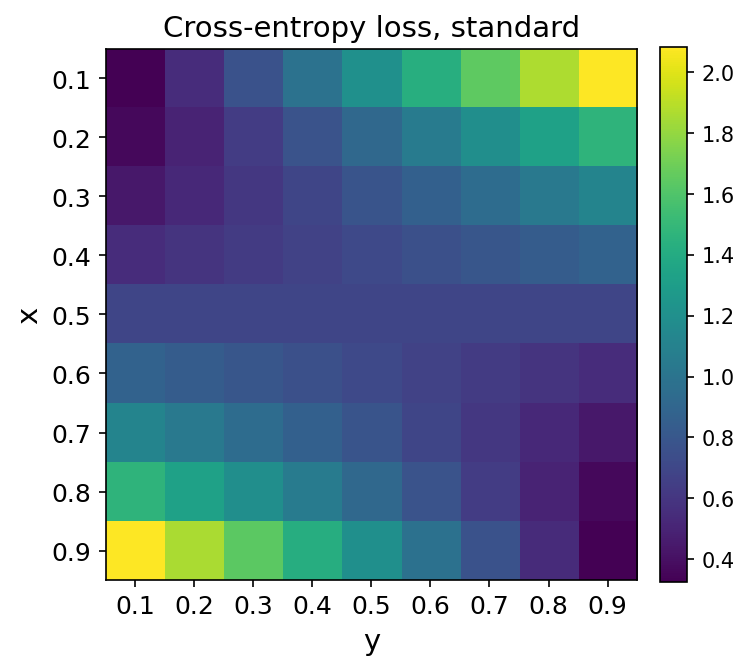

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = 1
y = 0

start = 0.1
stop = 1
step = 0.1
steps = torch.arange(start,stop,step)
results = np.zeros((len(steps),len(steps)))

logsigmoid = torch.nn.LogSigmoid()

for ind_x, x in enumerate(steps):
	for ind_y, y in enumerate(steps):
		loss = -(y*torch.log(x) + (1-y)*torch.log(1-x))
		results[ind_x,ind_y] = loss
plt.figure(figsize=(5,5),dpi=150)
plt.imshow(results)
# add x and y ticks
# Format tick labels to one decimal place to avoid weird floating point representations
tick_labels = [f"{v:.1f}" for v in steps]
plt.xticks(np.arange(len(tick_labels)), tick_labels, fontsize=12)
plt.yticks(np.arange(len(tick_labels)), tick_labels, fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Cross-entropy loss, standard", fontsize=14)
plt.xlabel("y", fontsize=14)
plt.ylabel("x", fontsize=14)
plt.show()

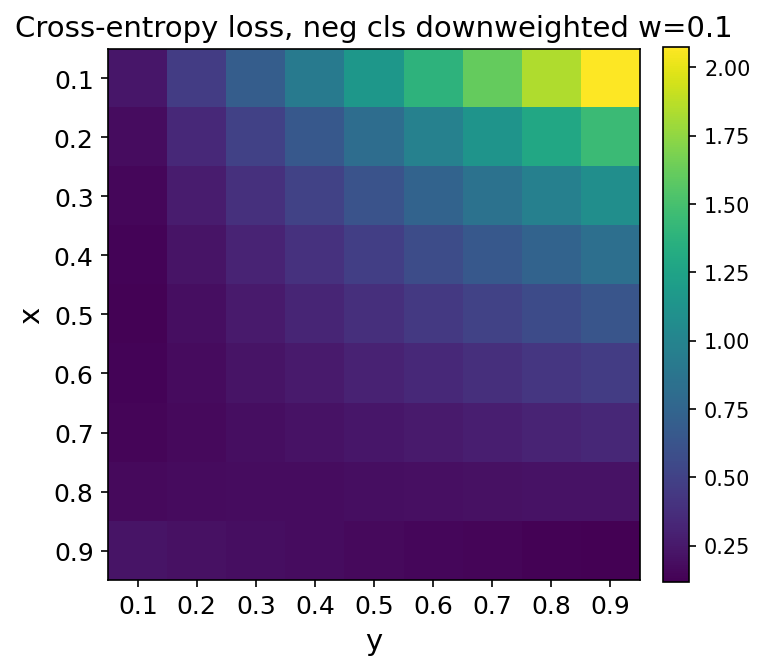

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = 1
y = 0

start = 0.1
stop = 1
step = 0.1
steps = torch.arange(start,stop,step)
results = np.zeros((len(steps),len(steps)))

logsigmoid = torch.nn.LogSigmoid()

for ind_x, x in enumerate(steps):
	for ind_y, y in enumerate(steps):
		y_neg_downweight = 0.1
		loss = -(y*torch.log(x) + y_neg_downweight*(1-y)*torch.log(1-x))
		results[ind_x,ind_y] = loss
plt.figure(figsize=(5,5),dpi=150)
plt.imshow(results)
# add x and y ticks
# Format tick labels to one decimal place to avoid weird floating point representations
tick_labels = [f"{v:.1f}" for v in steps]
plt.xticks(np.arange(len(tick_labels)), tick_labels, fontsize=12)
plt.yticks(np.arange(len(tick_labels)), tick_labels, fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title(f"Cross-entropy loss, neg cls downweighted w={y_neg_downweight}", fontsize=14)
plt.xlabel("y", fontsize=14)
plt.ylabel("x", fontsize=14)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = 1
y = 0

step = 0.1
results = np.zeros((int(1/step),int(1/step)))

logsigmoid = torch.nn.LogSigmoid()

for x in torch.arange(0,1,step):
	for y in torch.arange(0,1,step):
		# now what happens if we are sure that y==1, but not sure that y==0?
		# this happens when we have TSS in some non-primary transcript, so we don't want to penalize there
		y_zero_downweight = 0.01
		loss = -y*logsigmoid(torch.tensor(x)) - y_zero_downweight*(1-y)*logsigmoid(1-torch.tensor(x))
		results[int(x/step),int(y/step)] = loss
plt.figure(figsize=(10,10),dpi=50)
plt.imshow(results)
# add x and y ticks
# Format tick labels to one decimal place to avoid weird floating point representations
tick_labels = [f"{v:.1f}" for v in np.arange(0, 1, step)]
plt.xticks(np.arange(len(tick_labels)), tick_labels, fontsize=12)
plt.yticks(np.arange(len(tick_labels)), tick_labels, fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Cross-entropy loss, downweighting negative class", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.show()

## Gena tests

In [ ]:
import torch
from transformers import BertConfig, BertModel
from transformers.utils import cached_file

pretrained_cpt = "AIRI-Institute/gena-lm-bert-base-t2t"
hf_config = BertConfig.from_pretrained(pretrained_cpt)
bert = BertModel(hf_config, add_pooling_layer=False)
weights_path = cached_file(pretrained_cpt, "pytorch_model.bin")
state_dict = torch.load(weights_path, map_location="cpu")
missing_k, unexpected_k = bert.load_state_dict(state_dict, strict=False)
if len(missing_k) != 0:
	print (f"{missing_k} were not loaded from checkpoint! These parameters were randomly initialized.")
if len(unexpected_k) != 0:
	print (f"{unexpected_k} were found in checkpoint, but model is not expecting them!")

['embeddings.word_embeddings.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.LayerNorm.weight', 'embeddings.LayerNorm.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.intermediate.dense.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.output.dense.weight', 'encoder.layer.0.output.dense.bias', 'encoder.layer.0.output.LayerNorm.weight', 'encoder.layer.0.output.LayerNorm.bias', 'encoder.layer.1.attention.self.query.weight', 'encoder.layer.1.attention.self.query.bias', 'encod

In [1]:
from transformers import AutoTokenizer, AutoModel
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', trust_remote_code=True)
gena_module_name = model.__class__.__module__
import importlib
cls = getattr(importlib.import_module(gena_module_name), 'BertModel')
model = cls.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', add_pooling_layer=False)


/disk/10tb/home/fishman/miniconda3/envs/annotation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: Can't load config for 'AIRI-Institute/gena-lm-bert-base-t2t'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'AIRI-Institute/gena-lm-bert-base-t2t' is the correct path to a directory containing a config.json file

In [2]:
from transformers import AutoTokenizer, AutoModel
import transformers
print (transformers.__version__)
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-large-t2t', trust_remote_code=True)
gena_module_name = model.__class__.__module__
import importlib
cls = getattr(importlib.import_module(gena_module_name), 'BertModel')
model = cls.from_pretrained('AIRI-Institute/gena-lm-bert-large-t2t', add_pooling_layer=False)


4.56.1


A new version of the following files was downloaded from https://huggingface.co/AIRI-Institute/gena-lm-bert-large-t2t:
- modeling_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


ImportError: cannot import name 'apply_chunking_to_forward' from 'transformers.modeling_utils' (/disk/10tb/home/fishman/miniconda3/envs/annotation/lib/python3.10/site-packages/transformers/modeling_utils.py)

In [1]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t')
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', trust_remote_code=True)

/disk/10tb/home/fishman/miniconda3/envs/annotation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class cback():
	def __init__(self, trainer_instance):
		self.trainer_instance = trainer_instance

	def __call__(self):
		return self.trainer_instance.a

class Test():
	def __init__(self, cb):
		self.a = 1
		self.cb = cb(self)

	def run(self):
		return cb()

BertConfig {
  "_name_or_path": "AIRI-Institute/gena-lm-bert-base-t2t",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "auto_map": {
    "AutoModel": "AIRI-Institute/gena-lm-bert-base-t2t--modeling_bert.BertForMaskedLM"
  },
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "last_layer_norm": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 3,
  "position_embedding_type": "absolute",
  "pre_layer_norm": true,
  "transformers_version": "4.42.4",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 32000
}

In [1]:
from custom_trainer import LogTrainMetricsCallback, DetectTrainStepStart
l1 = LogTrainMetricsCallback()
l2 = DetectTrainStepStart()
l = [l1, l2]
from transformers.trainer_callback import DefaultFlowCallback
[DefaultFlowCallback] + l

/disk/10tb/home/fishman/miniconda3/envs/annotation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers.trainer_callback.DefaultFlowCallback,

In [ ]:
import torch
from custom_trainer import CustomTrainer
class M(torch.nn.Module):
	def __init__(self):
		super().__init__()
		self.a = 1
		self.b = 2
	def forward(self, x):
		return self.a*x + self.b
m = M()
t = CustomTrainer(model=m, callbacks=[l1, l2])

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


# test modernbert model loading

In [8]:
import sys
sys.path.append("/disk/10tb/home/fishman/DNALM/ModernBERT")
import os
import torch
# set CUDA_VISIBLE_DEVICES to 1
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
model_path = "/mnt/nfs_dna/minja/DNALM/ModernBERT/runs/moderngena-base-pretrain-promoters_multi_v2_resume_ep30-ba90700/"

In [9]:
!ls {model_path}

cfg.yaml  ep114-ba337200-rank0.pt  latest-rank0.pt


In [10]:
cfg_path = os.path.join(model_path, "cfg.yaml")

In [11]:
from src import flex_bert as flex_bert_module
from src.bert_layers.model import FlexBertModel
import src.bert_layers.configuration_bert as configuration_bert_module
from composer.utils.checkpoint import _ensure_valid_checkpoint
from omegaconf import DictConfig, OmegaConf as om

In [ ]:
cfg = om.load(cfg_path)
model_config = cfg["model"]["model_config"]
pretrained_model_name = "bert-base-uncased"
if isinstance(model_config, DictConfig):
	model_config = om.to_container(model_config, resolve=True)
config = configuration_bert_module.FlexBertConfig.from_pretrained(pretrained_model_name, **model_config)

model = FlexBertModel(config=config)

checkpoint_filepath = os.path.join(model_path, "latest-rank0.pt")	
print(f"Loading checkpoint from {checkpoint_filepath}")
state = torch.load(_ensure_valid_checkpoint(checkpoint_filepath), map_location="cpu")
state_dict = state.get("state", {})
model_state = state_dict.get("model", {})
assert len(model_state) > 0, "Model state is empty, please check the checkpoint and checkpoint path"
model_state = {k.replace("model.bert.", ""): v for k, v in model_state.items()}
test = model.load_state_dict(model_state, strict=False)

_ = model.cuda()

Loading checkpoint from /mnt/nfs_dna/minja/DNALM/ModernBERT/runs/moderngena-base-pretrain-promoters_multi_v2_resume_ep30-ba90700/latest-rank0.pt


/tmp/ipykernel_3125380/560262985.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(_ensure_valid_checkpoint(checkpoint_filepath), map_location="cpu")


In [ ]:
# Assert that load_state_dict reported exactly the expected key mismatches
expected_missing = []
expected_unexpected = {
	"model.head.dense.weight",
	"model.head.norm.weight",
	"model.decoder.weight",
	"model.decoder.bias",
}

assert test.missing_keys == expected_missing, f"missing_keys mismatch: {test.missing_keys}"
assert set(test.unexpected_keys) == expected_unexpected and len(test.unexpected_keys) == len(expected_unexpected), \
	f"unexpected_keys mismatch: {test.unexpected_keys}"


In [40]:
import torch
test_input = torch.randint(0, 100, (1, 10)).to(model.device)
outputs = model(test_input, return_dict=True)

In [44]:
outputs.size()

torch.Size([1, 10, 768])

### test viard pysam behaviour

In [1]:
import pysam

In [3]:
fa = pysam.FastaFile("/disk/10tb/home/fishman/DNALM/GENA_LM/data/annotation/T2T-CHM13v2.0_genomic.fna")

In [4]:
fa.fetch("NC_060944.1",53_428_417,53_429_496)


'GCACTCCCCTAGTTGTGACAAGATATGTCACCAAATGTCCAACAGAGGCCAAAATCACCCTCGGCTTAGAACCACTGTTTAAGCTCACAATCTTCTTGGTTTACAACAGAAGGCAACAACCTCATCTGGTACCATATGCAAGTAACAACCATCAGCAACAAGCAATCCAGGGCAGTCCAGCAAGGCGTCAGGAACAGCCAGAGGAAACCTTGGCCGGATGGGACTCACTGCAAAACGGCACCTGGCTCCCCACTGAAGCTAGACTTTCGGGTGTAATGGTAACTGTGCTCAAGTTTTGCCTTGCAGGCTGACTTTAGACCCCAGCTCTTGCCTGAGAGGCAGCTCCATGGCATACAACTGGCCTTCTCCATCCCTTCCTTTCCAACTGGCAACACAGCTCAGCCCCTGAAAGGCCAGGAATGGGTTAAGTCTTGGAAAAATGGTtttgagcaacatggtaaaaagaGCACTGAAGGGTAACCAAAGCTAAGCCTTATTCTTGGATGGGTGGCAAGCAGCTAGGACACCTGCAGCAAGTGGTGTCTGTCCTCTGAGGCTGTTTCCTGTCAACGAGAggagtggccgggcacggtggctcacgcctgtaataccagcactttgggaggccaaggcgggtggatcacttgaggtcaggagttcaagaccagcctgccgaacatggtaaaaccctgtctctacaaaaatacaaaaattagctgggtgtggtggcactgtaatcccagctactcgggaggctgaggcaggagaggagtgAACTAGAGGTGGTTTTCAATCCATGCTCCACACTGAGCCCCAGGAATCCTAAGAAATCCGCTCAGCACCACCAACTGCAGCAGGATGGGAGATGCAGCCTGCAGCTCCGTTCCTCTGTCACACATCGGGTGCCACctatgcttcctttttttttttttttttttttgagacatgagtctcactctgtcacccaggctggagtgcagtggcatgatctcagctcac

In [5]:
full_chr = fa.fetch("NC_060944.1")

In [16]:
full_chr.upper().find("CACAGCAGTCTGAGATCAAACTGCAAGATGGCAGTGAGGCTGGGGGAGGGGCGCCCGCCATTGCCCAGGCTTGCTTAGGTAAACAAAGCAGCCGGGAAGCTCCAACTGGGCCCAGCCCACCACAGCTCAAGGAGTCCTGCCTGCCTCTGTAGGCTCCACCTCTGGGGGCAG")

55245312

In [17]:
s = "CACAGCAGTCTGAGATCAAACTGCAAGATGGCAGTGAGGCTGGGGGAGGGGCGCCCGCCATTGCCCAGGCTTGCTTAGGTAAACAAAGCAGCCGGGAAGCTCCAACTGGGCCCAGCCCACCACAGCTCAAGGAGTCCTGCCTGCCTCTGTAGGCTCCACCTCTGGGGGCAG"
print (full_chr[55_245_312:55_249_312].upper())
# print (s)
# print (full_chr[55201761:55201840].upper() == s)


CACAGCAGTCTGAGATCAAACTGCAAGATGGCAGTGAGGCTGGGGGAGGGGCGCCCGCCATTGCCCAGGCTTGCTTAGGTAAACAAAGCAGCCGGGAAGCTCCAACTGGGCCCAGCCCACCACAGCTCAAGGAGTCCTGCCTGCCTCTGTAGGCTCCACCTCTGGGGGCAGGGCACAGACAAACAAAAAGACAGCAGTAACCTCTGCAGACTTAAATGTCCCTGTCTGACAGCTTTGAAGAGAGCAGTGGTTCTCCCAGCACGCAGCTGGAGATCTGAGAACGGGCAGACTGCCTCCTCAAGTGGGTCCCTGACCCCTGACCCCCGAGCAGCCTAACTGGCAGGCACCCCCCAGCAGGGGCACACTGACACCTCACACGGCAGGGTATTCCAACAGACCTGTGGCTGAGGGTCCTGTCTGTTAGAAGGAAAACTAACAAACAGAATGGACATCCACACCAAAAACCCATCTGTACATCACCATCATCAAAGACCAAAAGTAGATAAAACCACAAAGATGGGGAAAAAACAGAACAGAAAAACTGGAAACTCTAAAACGCAGAGCGCCTCTCCTCCTCCAAAGGAACGCAGTTCCTCACCAGCAACGGAACAAAGCTGGATGGAGAATGACTTTGACGAGCTGAGAGAAAAAGGCTTCAGACGATCAAATTACTCTGAGCTACGGGAGGACATTCAAACCAAAGGCAAAGAAGTTGAAAACTTTGAAAAAACTTTAGAAGAATGTATAACTAGAATAACCAATACAGAGAAGTGCTTAAAGGAGCTGATGGAGCTGAAAACCAAGGCTGGAGAACTACGTGAAGAAGGCAGAAACCTCAGGAAGCGATGCAATCAACTGGAAGAAAGGGTATCAGCGATGGAAGATGAAATGAATGAAATGAAGCGAGAAGAGAAGTTTAGAGAAAAAAGAATAAAAAGAAATGAGCAAAGCCTCCAAGAAATATGGGACTATGTGAAAAGACCAAATCTACGTCTGATTG

In [21]:
print (fa.references.index("NC_060944.1"))

19


In [22]:
print (fa.lengths[19])

66210255


In [23]:
seq = fa.fetch("NC_060944.1", 55245312,55252224).upper()
print (seq)

CACAGCAGTCTGAGATCAAACTGCAAGATGGCAGTGAGGCTGGGGGAGGGGCGCCCGCCATTGCCCAGGCTTGCTTAGGTAAACAAAGCAGCCGGGAAGCTCCAACTGGGCCCAGCCCACCACAGCTCAAGGAGTCCTGCCTGCCTCTGTAGGCTCCACCTCTGGGGGCAGGGCACAGACAAACAAAAAGACAGCAGTAACCTCTGCAGACTTAAATGTCCCTGTCTGACAGCTTTGAAGAGAGCAGTGGTTCTCCCAGCACGCAGCTGGAGATCTGAGAACGGGCAGACTGCCTCCTCAAGTGGGTCCCTGACCCCTGACCCCCGAGCAGCCTAACTGGCAGGCACCCCCCAGCAGGGGCACACTGACACCTCACACGGCAGGGTATTCCAACAGACCTGTGGCTGAGGGTCCTGTCTGTTAGAAGGAAAACTAACAAACAGAATGGACATCCACACCAAAAACCCATCTGTACATCACCATCATCAAAGACCAAAAGTAGATAAAACCACAAAGATGGGGAAAAAACAGAACAGAAAAACTGGAAACTCTAAAACGCAGAGCGCCTCTCCTCCTCCAAAGGAACGCAGTTCCTCACCAGCAACGGAACAAAGCTGGATGGAGAATGACTTTGACGAGCTGAGAGAAAAAGGCTTCAGACGATCAAATTACTCTGAGCTACGGGAGGACATTCAAACCAAAGGCAAAGAAGTTGAAAACTTTGAAAAAACTTTAGAAGAATGTATAACTAGAATAACCAATACAGAGAAGTGCTTAAAGGAGCTGATGGAGCTGAAAACCAAGGCTGGAGAACTACGTGAAGAAGGCAGAAACCTCAGGAAGCGATGCAATCAACTGGAAGAAAGGGTATCAGCGATGGAAGATGAAATGAATGAAATGAAGCGAGAAGAGAAGTTTAGAGAAAAAAGAATAAAAAGAAATGAGCAAAGCCTCCAAGAAATATGGGACTATGTGAAAAGACCAAATCTACGTCTGATTG

In [26]:
tok(seq).input_ids.index(12)

ValueError: 12 is not in list

In [28]:
tok.decode(12)[0]

'N'

# bcftools consensus

In [13]:
import subprocess

ref = "/mnt/nfs_dna/minja/hg38.fa"

In [ ]:
start = 10524871
end = start + 1000
region = f"chr22:{start}-{end}"
ref = "/mnt/nfs_dna/minja/hg38.fa"
vcf_file = "../../data/annotation/1kg/tmp.bcf"
sample = "HG00107"
haplotype = "2pIu"

# Run samtools faidx and pipe to bcftools consensus
samtools_cmd = [
	"samtools", "faidx", ref, region
]
bcftools_cmd = [
	"bcftools", "consensus",
	"--sample", sample,
	"--haplotype", haplotype,
	"--include", "MAX(ILEN)=0",
	vcf_file
]

try:
	samtools_proc = subprocess.Popen(
		samtools_cmd,
		stdout=subprocess.PIPE,
		stderr=subprocess.PIPE
	)
	bcftools_proc = subprocess.Popen(
		bcftools_cmd,
		stdin=samtools_proc.stdout,
		stdout=subprocess.PIPE,
		stderr=subprocess.PIPE,
		text=True
	)
	samtools_proc.stdout.close()  # Allow samtools to receive a SIGPIPE if bcftools exits
	out, err = bcftools_proc.communicate()
	if bcftools_proc.returncode != 0:
		print("bcftools consensus error:", err)
	else:
		# print ("Done!")
		print("".join(out.split("\n")[1:]))
except Exception as e:
	print("Error running pipeline:", e)



GGTTCTGTTCTTTTCCTTCCATTTGGTTCTCTGATATTTTCTTCATGGTTGCCATTACATCACATATTCAATATTATGACCCACTTTGTGTTTCAGTCAGTGTCTATACATACAACTTTGAATGATACAAATGTCTCATAGAAACTAAGTTTAATCAAATCAAGAAACTAAGTTTAATGCCAGTCTATATCAATGTACCGTTTCCTTCTAGCTAAATATTTAGGCTTTTCCAAATTTTGTTAACATAAATAACTCCAAAGATATTTTTGTTAACATTTTCTCTTAGTGTTACTTTCCTAAGGTAGACTTTAACAATTTACTATAACAAATTATAGAAAATGATCATTTTAAGGTTCCTTATTCTTGTACTATTTGTAAATAATGTTATCACTTCTTTCGAATTATTTCTTCTTGATATTTTATTGCATTGATCAGAATTCTCAGAATTGTAATATAATGTTAATTATTAAATATTACATTCCTTCTCATGTTAATAGTTATTATTTTGTAAATATGATGCTATTAGCAAATTTTAGATTGGCATCCTTAATATATTATTCAGATGTTAGCAATTGCACTTTTCCCTAAAAAGGCTCTTTTTGTGGCTTTTTGTCCCCGCCATGGCTTTTTACCGCCGCAGTATTTTGCCCCCGCCGCCGTGGGTTTCAGTCCCCGCCGCCGCGGCTTTTGGCCCCCGCCGCCACTCTTTTGACAACGCGGCTTTTTGCCCCCGCCGCCGAGGCTTTTTGCCGCCGTGGCTTTTTACCCCAGCCGCCGGTGTTTTTTGCGACTTTTTCCCCCCGCCGCCGCCCTCGCGGCTTTTTTTGCCCCCGCTCCAGATGGTTTTTGCCCCCACCACCGCGGCTTTTTGCCCGCGCCGCCGGGGCTTTTTGCCACCGCGGTATTTTGCCCCCGCCGCCGCGGCTTTTGCGGCTTTTTGACCCCGCCGCCGCGGCTTTTGCCGACACGGCTTTTTACCCCCCGCTGCCGCGGCTTTTTG

In [34]:
vcf = pysam.VariantFile(vcf_file)
print (list(vcf.header.samples))

['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101', 'HG00102', 'HG00103', 'HG00105', 'HG00106', 'HG00107', 'HG00108', 'HG00109', 'HG00110', 'HG00111', 'HG00112', 'HG00113', 'HG00114', 'HG00115', 'HG00116', 'HG00117', 'HG00118', 'HG00119', 'HG00120', 'HG00121', 'HG00122', 'HG00123', 'HG00125', 'HG00126', 'HG00127', 'HG00128', 'HG00129', 'HG00130', 'HG00131', 'HG00132', 'HG00133', 'HG00136', 'HG00137', 'HG00138', 'HG00139', 'HG00140', 'HG00141', 'HG00142', 'HG00143', 'HG00145', 'HG00146', 'HG00148', 'HG00149', 'HG00150', 'HG00151', 'HG00154', 'HG00155', 'HG00157', 'HG00158', 'HG00159', 'HG00160', 'HG00171', 'HG00173', 'HG00174', 'HG00176', 'HG00177', 'HG00178', 'HG00179', 'HG00180', 'HG00181', 'HG00182', 'HG00183', 'HG00185', 'HG00186', 'HG00187', 'HG00188', 'HG00189', 'HG00190', 'HG00231', 'HG00232', 'HG00233', 'HG00234', 'HG00235', 'HG00236', 'HG00237', 'HG00238', 'HG00239', 'HG00240', 'HG00242', 'HG00243', 'HG00244', 'HG00245', 'HG00246', 'HG00250', 'HG00251', 'HG00252', 'HG00253'

In [36]:
list(vcf.header.contigs)

['chr1',
 'chr2',
 'chr3',
 'chr4',
 'chr5',
 'chr6',
 'chr7',
 'chr8',
 'chr9',
 'chr10',
 'chr11',
 'chr12',
 'chr13',
 'chr14',
 'chr15',
 'chr16',
 'chr17',
 'chr18',
 'chr19',
 'chr20',
 'chr21',
 'chr22',
 'chrX',
 'chrY']